In [47]:
import pandas as pd
import numpy as np
import seaborn as sb
from sklearn import metrics
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import skew
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from xgboost import plot_importance
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, accuracy_score, r2_score, f1_score,\
roc_auc_score,mean_absolute_error,mean_absolute_percentage_error,max_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

In [48]:
data_fin_imprt=pd.read_csv("final.csv",  delimiter=',')

In [49]:
x=data_fin_imprt.drop('SalePrice',axis=1)
y=data_fin_imprt['SalePrice']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [50]:
xgb_mod = xgb.XGBRegressor(objective="reg:squarederror", max_depth=10,gamma=0.001,min_child_weight=50,subsample=1)
xgb_mod.fit(x_train, y_train)
xgb_pred = xgb_mod.predict(x_test)

In [51]:
xgb_mod_sc=xgb_mod.score(x_train,y_train)
print('XGB Regression Model Score  : ',round(xgb_mod_sc,3))
r2=r2_score(y_test,xgb_pred)
print('R Sq. Value : ',round(r2,2))
rfr_adj_r2 = 1 - (1-r2) * (len(y)-1)/(len(y)-x.shape[1]-1)
print('Adjusted R Sq. Value is : ', round(rfr_adj_r2,3))
mean_sq=mean_squared_error(y_test,xgb_pred)
print('Mean Square Error is : ', round(mean_sq,3))
lin_rmse=np.sqrt(mean_squared_error(y_test,xgb_pred))
print('Root Mean Square Error is : ', round(lin_rmse,3))
lin_mae=mean_absolute_error(y_test, xgb_pred)
print('Mean Absoulue Error is : ', round(lin_mae,3))
scores_cvs = cross_val_score(xgb_mod, x, y,scoring='r2' ,cv=5)
print("Accuracy :",round(scores_cvs.mean()*100,2),"%")

XGB Regression Model Score  :  0.984
R Sq. Value :  0.93
Adjusted R Sq. Value is :  0.924
Mean Square Error is :  0.013
Root Mean Square Error is :  0.112
Mean Absoulue Error is :  0.082
Accuracy : 89.47 %


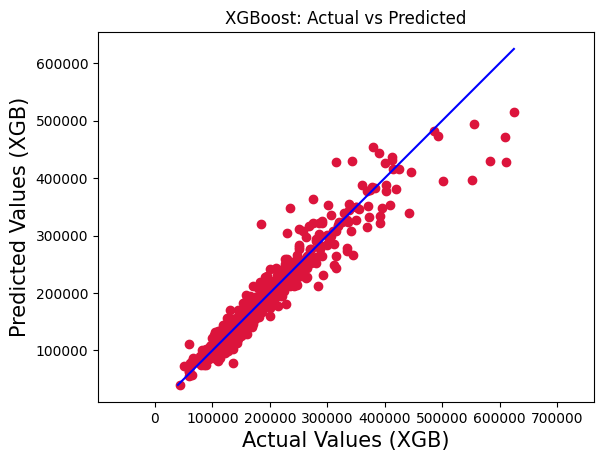

In [52]:
Actual_Price=np.expm1(y_test)
Predicted_Price_XGB=np.expm1(xgb_pred)
plt.scatter(Actual_Price, Predicted_Price_XGB, c='crimson')
p1 = max(max(Predicted_Price_XGB), max(Actual_Price))
p2 = min(min(Predicted_Price_XGB), min(Actual_Price))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('Actual Values (XGB)', fontsize=15)
plt.ylabel('Predicted Values (XGB)', fontsize=15)
plt.title('XGBoost: Actual vs Predicted')
plt.axis('equal')
plt.show()

C:\Users\revex\AppData\Local\Temp\ipykernel_28300\1922169834.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot((y_test - xgb_pred), bins=100)


Text(0.5, 1.0, 'XGBoost: Residuals')

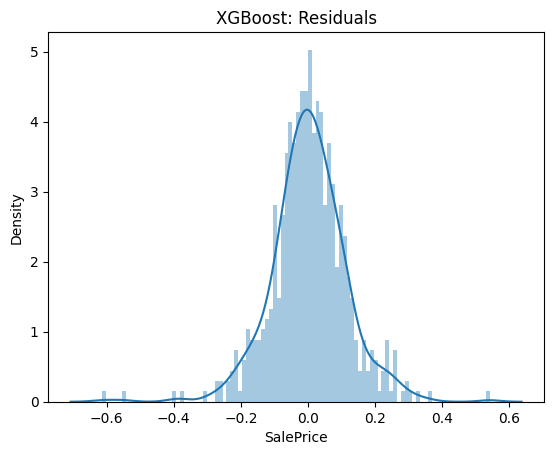

In [53]:
sb.distplot((y_test - xgb_pred), bins=100)
plt.title("XGBoost: Residuals")

In [54]:
# Our Weighted Ensemble Approach (XGBoost = 0.8 | Random Forest = 0.1 | Linear Regression = 0.1)
# ----------

rf_mod = RandomForestRegressor(random_state=42)
lin_mod = LinearRegression()
rf_mod.fit(x_train, y_train)
lin_mod.fit(x_train, y_train)
rf_pred = rf_mod.predict(x_test)
lin_pred = lin_mod.predict(x_test)

# Weights
w1 = 0.8   # For XGBoost
w2 = 0.1   # For Random Forest
w3 = 0.1   # For Linear Regression
ensemble_pred = (w1 * xgb_pred) + (w2 * rf_pred) + (w3 * lin_pred)

In [55]:
ens_train_pred = (w1 * xgb_mod.predict(x_train) + w2 * rf_mod.predict(x_train)+ w3 * lin_mod.predict(x_train))

ens_model_score=r2_score(y_train, ens_train_pred)
print('Ensemble Regression Model Score  : ',round(ens_model_score,3))
ens_r2=r2_score(y_test, ensemble_pred)
print('R Sq. Value : ',round(ens_r2,2))
ens_adj = 1 - (1-ens_r2) * (len(y)-1)/(len(y)-x.shape[1]-1)
print('Adjusted R Sq. Value is : ', round(ens_adj,3))
ens_mse=mean_squared_error(y_test, ensemble_pred)
print('Mean Square Error is : ', round(ens_mse,3))
ens_rmse=np.sqrt(ens_mse)
print('Root Mean Square Error is : ', round(ens_rmse,3))
ens_mae=mean_absolute_error(y_test, ensemble_pred)
print('Mean Absoulue Error is : ', round(ens_mae,3))

# CV Accuracy (manual calculation because our weighted ensemble approach does not have built-in estimators)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ensemble_cv_scores = []

for train_idx, test_idx in kf.split(x):
    X_tr, X_te = x.iloc[train_idx], x.iloc[test_idx]
    Y_tr, Y_te = y.iloc[train_idx], y.iloc[test_idx]

    xgb_mod.fit(X_tr, Y_tr)
    rf_mod.fit(X_tr, Y_tr)
    lin_mod.fit(X_tr, Y_tr)

    p1 = xgb_mod.predict(X_te)
    p2 = rf_mod.predict(X_te)
    p3 = lin_mod.predict(X_te)

    p_ens = (w1*p1) + (w2*p2) + (w3*p3)
    ensemble_cv_scores.append(r2_score(Y_te, p_ens))
print("Accuracy :",round(np.mean(ensemble_cv_scores)*100,2),"%")

Ensemble Regression Model Score  :  0.983
R Sq. Value :  0.94
Adjusted R Sq. Value is :  0.932
Mean Square Error is :  0.011
Root Mean Square Error is :  0.107
Mean Absoulue Error is :  0.077
Accuracy : 90.62 %


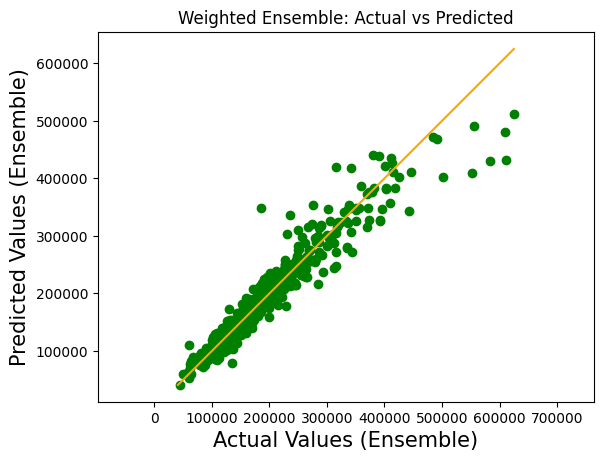

In [56]:
Predicted_Price_Ens=np.expm1(ensemble_pred)
plt.scatter(Actual_Price, Predicted_Price_Ens, c='green')
p1 = max(max(Predicted_Price_Ens), max(Actual_Price))
p2 = min(min(Predicted_Price_Ens), min(Actual_Price))
plt.plot([p1, p2], [p1, p2], 'orange')
plt.xlabel('Actual Values (Ensemble)', fontsize=15)
plt.ylabel('Predicted Values (Ensemble)', fontsize=15)
plt.title('Weighted Ensemble: Actual vs Predicted')
plt.axis('equal')
plt.show()

C:\Users\revex\AppData\Local\Temp\ipykernel_28300\3501241954.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot((y_test - ensemble_pred), bins=100, color='green')


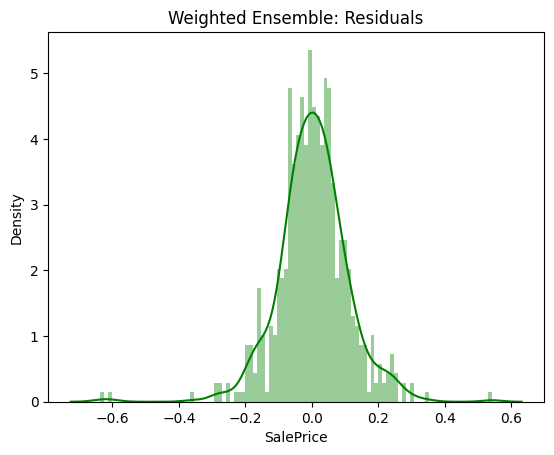

In [57]:
sb.distplot((y_test - ensemble_pred), bins=100, color='green')
plt.title("Weighted Ensemble: Residuals")
plt.show()